**Задача**: собрание базы поставщиков и создание списка сырья для производства

* мы хотим создавать сорбет малина-личи -> для определения базового состава возьмем состав сорбета малина-личи от ВкусВилла, который уже продается на рынке. 

In [256]:
import requests
import time
import re
import pandas as pd
from bs4 import BeautifulSoup

In [257]:
#берем с сайта вкусвилла
headers = {'User-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36',
'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7', 
'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7'}

url = 'https://ecobroccolini.ru/catalog/poleznye-produkty/sladosti/morozhenoe/57639/'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [258]:
soup = BeautifulSoup(response.text, 'html.parser')
sostav_block = soup.find('div', class_='detail_sostav')
ingredient_spans = sostav_block.find_all('span')
ingredients = []
for span in ingredient_spans:
    ingredient_text = span.get_text(strip=True)
    ingredients.append(ingredient_text)

clean_ingredients = []
for item in ingredients:
    if item != 'стабилизаторы(':

        cleaned = item.replace(',', '').replace('(', '').replace(')', '').lower()
        clean_ingredients.append(cleaned.strip())

clean_ingredients = set(clean_ingredients)
clean_ingredients

{'вода минеральная природная столовая питьевая',
 'гуаровая камедь',
 'желатин пищевой',
 'камедь рожкового дерева',
 'лимонный сок прямого отжима',
 'наполнитель "личи"',
 'пюре из личи замороженное',
 'пюре из малины замороженное',
 'сахар',
 'сироп глюкозный сухой'}

_________________________________________________________________________________________________________________________________________________

Будем собирать данные о поставщиках в датафреймы по 2 основным продуктам: фруктовое пюре и сахар

*  Популярные поставщики фруктового пюре оптом для анализа: Две Морковки ([ссылка](https://dvemorkovki.ru/catalog/ingredients/fruit-puree/filter/clear/apply/)), Ягодный мастер ([ссылка](https://berrymaster.ru/catalog/berrymesh/)), Пекр ([ссылка](https://pekr.ru/catalog/?q=%D0%BF%D1%8E%D1%80%D0%B5+%D0%BC%D0%B0%D0%BB%D0%B8%D0%BD%D0%B0&s=%D0%9D%D0%B0%D0%B9%D1%82%D0%B8)), Италика ([ссылка](https://www.italika.ru/catalog/fruktovoe-pyure))

**Две морковки**

In [259]:
malina_url = 'https://dvemorkovki.ru/catalog/ingredients/fruit-puree/filter/product_type-is-malina/apply/'

response = requests.get(malina_url, headers = headers)
response

<Response [200]>

In [260]:
def extract_weight(name):
    gram_match = re.search(r'(\d+(?:[.,]\d+)?)\s*г', name)
    if gram_match:
        weight = float(gram_match.group(1).replace(',', '.'))
        return weight
    
    kg_match = re.search(r'(\d+(?:[.,]\d+)?)\s*к?г', name)
    if kg_match:
        weight_kg = float(kg_match.group(1).replace(',', '.'))
        grams = weight_kg * 1000
        return grams
    
    t_match = re.search(r'(\d+(?:[.,]\d+)?)\s*т', name)
    if t_match:
        weight_t = float(t_match.group(1).replace(',', '.'))
        grams = weight_t * 1000 * 1000
        return grams
    
    num_match = re.search(r'(\d+(?:[.,]\d+)?)', name)
    if num_match:
        return float(num_match.group(1).replace(',', '.'))
    
    return None

In [261]:
def extract_price(name):
    price = name.replace('руб.', '').strip()
    price = price.replace(' ', '')
    price = price.replace("'", '')
    return float(price)

In [262]:
malina_data = {}

In [263]:
malina_data['Две морковки'] = {}

soup = BeautifulSoup(response.text, 'html.parser')
product_cards = soup.find_all('div', class_ = "product-card product-card_block")
for product in product_cards:
    name = product.find('a', class_="product-card__title").text
    name = name.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    name = re.sub(r'\s+', ' ', name)
    name = name.strip()
    if 'малина' in name.lower():
        weight_g = extract_weight(name)
        weight_kg = weight_g / 1000
        price_el = product.find('span', class_="product-card__price").text
        price = extract_price(price_el)
        price_kg = (price / weight_g) * 1000
        time.sleep(1)
        malina_data['Две морковки'][name] = {'price_kg' : price_kg, 'weight_kg' : weight_kg}

print(malina_data)

{'Две морковки': {'Пюре замороженное Малина-Маракуйя, Proff Puree, Россия, 500 г': {'price_kg': 1298.0, 'weight_kg': 0.5}, 'Пюре замороженное The Essentials Малина, Ravifruit, Франция, 1 кг': {'price_kg': 1390.0, 'weight_kg': 1.0}, 'Пюре пастеризованное Малина, Ravifruit, Франция, 1 кг': {'price_kg': 1909.0, 'weight_kg': 1.0}, 'Пюре замороженное Малина, Ravifruit, Франция, 1 кг': {'price_kg': 1590.0, 'weight_kg': 1.0}, 'Пюре замороженное Малина, Fresh Harvest, Россия, 250 г': {'price_kg': 1596.0, 'weight_kg': 0.25}, 'Пюре замороженное Малина, Fresh Harvest, Россия, 1 кг': {'price_kg': 1150.0, 'weight_kg': 1.0}, 'Пюре замороженное Малина без сахара, Proff Puree, Россия, 500 г Без сахара': {'price_kg': 1298.0, 'weight_kg': 0.5}, 'Пюре замороженное Малина-Клюква-Гибискус, Ravifruit, Франция, 1 кг': {'price_kg': 3079.0, 'weight_kg': 1.0}, 'Пюре замороженное Малина, Organic Bar, Россия, 200 г': {'price_kg': 1395.0, 'weight_kg': 0.2}}}


In [264]:
rows = []

for shop, products in malina_data.items():
    for product_name, product_info in products.items():
        rows.append({
            'магазин': shop,
            'товар': product_name,
            'цена за кг': product_info['price_kg'],
            'вес продажи в кг': product_info['weight_kg']
        })

df_malina = pd.DataFrame(rows)

df_malina

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре замороженное Малина-Маракуйя, Proff Puree...",1298.0,0.50
1,Две морковки,"Пюре замороженное The Essentials Малина, Ravif...",1390.0,1.00
2,Две морковки,"Пюре пастеризованное Малина, Ravifruit, Франци...",1909.0,1.00
3,Две морковки,"Пюре замороженное Малина, Ravifruit, Франция, ...",1590.0,1.00
4,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1596.0,0.25
5,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1150.0,1.00
6,Две морковки,"Пюре замороженное Малина без сахара, Proff Pur...",1298.0,0.50
7,Две морковки,"Пюре замороженное Малина-Клюква-Гибискус, Ravi...",3079.0,1.00
8,Две морковки,"Пюре замороженное Малина, Organic Bar, Россия,...",1395.0,0.20


In [265]:
lichi_url = 'https://dvemorkovki.ru/catalog/ingredients/fruit-puree/filter/product_type-is-lichi/apply/'

response = requests.get(lichi_url, headers = headers)
response

<Response [200]>

In [266]:
lichi_data = {}

lichi_data['Две морковки'] = {}

soup = BeautifulSoup(response.text, 'html.parser')
product_cards = soup.find_all('div', class_ = "product-card product-card_block")
for product in product_cards:
    name = product.find('a', class_="product-card__title").text
    name = name.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    name = re.sub(r'\s+', ' ', name)
    name = name.strip()
    if 'личи' in name.lower():
        weight_g = extract_weight(name)
        weight_kg = weight_g / 1000
        price_el = product.find('span', class_="product-card__price").text
        price = extract_price(price_el)
        price_kg = (price / weight_g) * 1000
        time.sleep(1)
        lichi_data['Две морковки'][name] = {'price_kg' : price_kg, 'weight_kg' : weight_kg}

print(lichi_data)

{'Две морковки': {'Пюре пастеризованное Личи, Ravifruit, Франция, 1 кг': {'price_kg': 1650.0, 'weight_kg': 1.0}, 'Пюре замороженное Личи, Fresh Harvest, Россия, 1 кг': {'price_kg': 1190.0, 'weight_kg': 1.0}, 'Пюре замороженное Личи, Ravifruit, Франция, 1 кг': {'price_kg': 1875.0, 'weight_kg': 1.0}, 'Пюре замороженное Личи, Organic Bar, Россия, 200 г': {'price_kg': 1425.0, 'weight_kg': 0.2}}}


In [267]:
rows = []

for shop, products in lichi_data.items():
    for product_name, product_info in products.items():
        rows.append({
            'магазин': shop,
            'товар': product_name,
            'цена за кг': product_info['price_kg'],
            'вес продажи в кг': product_info['weight_kg']
        })

df_lichi = pd.DataFrame(rows)

df_lichi

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре пастеризованное Личи, Ravifruit, Франция,...",1650.0,1.0
1,Две морковки,"Пюре замороженное Личи, Fresh Harvest, Россия,...",1190.0,1.0
2,Две морковки,"Пюре замороженное Личи, Ravifruit, Франция, 1 кг",1875.0,1.0
3,Две морковки,"Пюре замороженное Личи, Organic Bar, Россия, 2...",1425.0,0.2


**Ягодный мастер**

In [268]:
url = 'https://berrymaster.ru/catalog/berrymesh/'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [269]:
soup = BeautifulSoup(response.text, 'html.parser')
products = soup.find_all('a', attrs={'data-goal': 'catalog_product_title_click'})


In [270]:
products = soup.find_all('a', attrs={'data-goal': 'catalog_product_title_click'})

malina = {}
lichi = {}

for product_link in products:
    name = product_link.text.strip()
    if 'малин' in name.lower():
        form = product_link.find_parent('form', class_='ms2_form')
        
        price_span = form.find('span', class_='msoptionsprice-cost')
        price = price_span.text.strip()

        weight_kg = 1.0
        
        malina = {
            'магазин': 'Ягодный мастер',
            'товар': name,
            'цена за кг': price,
            'вес продажи в кг': weight_kg}

    if 'личи' in name.lower():
        form = product_link.find_parent('form', class_='ms2_form')
        
        price_span = form.find('span', class_='msoptionsprice-cost')
        price = price_span.text.strip()

        weight_kg = 1.0
        
        lichi = {
            'магазин': 'Ягодный мастер',
            'товар': name,
            'цена за кг': price,
            'вес продажи в кг': weight_kg}

print(malina)
print(lichi)

{'магазин': 'Ягодный мастер', 'товар': 'Пюре из малины', 'цена за кг': '715', 'вес продажи в кг': 1.0}
{}


In [271]:
df_malina = pd.concat([df_malina, pd.DataFrame([malina])], ignore_index=True)
df_malina

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре замороженное Малина-Маракуйя, Proff Puree...",1298.0,0.50
1,Две морковки,"Пюре замороженное The Essentials Малина, Ravif...",1390.0,1.00
2,Две морковки,"Пюре пастеризованное Малина, Ravifruit, Франци...",1909.0,1.00
3,Две морковки,"Пюре замороженное Малина, Ravifruit, Франция, ...",1590.0,1.00
4,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1596.0,0.25
5,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1150.0,1.00
6,Две морковки,"Пюре замороженное Малина без сахара, Proff Pur...",1298.0,0.50
7,Две морковки,"Пюре замороженное Малина-Клюква-Гибискус, Ravi...",3079.0,1.00
8,Две морковки,"Пюре замороженное Малина, Organic Bar, Россия,...",1395.0,0.20
9,Ягодный мастер,Пюре из малины,715,1.00


**Пекр**

In [272]:
malina_url = 'https://pekr.ru/catalog/?q=%D0%BF%D1%8E%D1%80%D0%B5+%D0%BC%D0%B0%D0%BB%D0%B8%D0%BD%D0%B0&s=%D0%9D%D0%B0%D0%B9%D1%82%D0%B8'

response = requests.get(malina_url, headers = headers)
response

<Response [200]>

In [273]:
soup = BeautifulSoup(response.text, 'html.parser')

In [274]:
malina = []

products = soup.find_all('div', attrs = {'data-product_type': "1"} )
for product in products:
    name_item = product.find('div', class_ = "inner_wrap TYPE_2")
    name_el = name_item.find('meta', attrs = {'itemprop': "description"})
    name = name_el.get('content')
    if 'малина' in name.lower():
        weight = float(extract_weight(name))
        weight_kg = weight/1000

        price_el = product.find('div', class_ = 'price_value_block values_wrapper')
        price_i = price_el.find('span', class_ = 'price_value')
        price_text = price_i.text.strip()
        price_text = re.sub(r'[^\d.,]', '', price_text)
        price_text = price_text.replace(',', '.')
        price = float(price_text)

        price_kg = price / weight_kg

        malina.append({'магазин':'Пекр',
                        'товар': name,
                        'цена за кг': price_kg,
                        'вес продажи в кг': weight_kg})

print(malina)

[{'магазин': 'Пекр', 'товар': 'Пюре Малина, Fresh Harvest,  250 г', 'цена за кг': 1720.0, 'вес продажи в кг': 0.25}, {'магазин': 'Пекр', 'товар': 'Замороженное пюре, саше Малина, Proff Puree, 250 г', 'цена за кг': 1180.0, 'вес продажи в кг': 0.25}, {'магазин': 'Пекр', 'товар': 'Замороженное фруктовое пюре Proff Puree Малина, 500 г', 'цена за кг': 1090.0, 'вес продажи в кг': 0.5}, {'магазин': 'Пекр', 'товар': 'Замороженное фруктовое пюре Proff Puree Малина, 1000 г', 'цена за кг': 1095.0, 'вес продажи в кг': 1.0}, {'магазин': 'Пекр', 'товар': 'Замороженное фруктовое пюре Proff Puree Малина без сахара, 500 г', 'цена за кг': 1190.0, 'вес продажи в кг': 0.5}, {'магазин': 'Пекр', 'товар': 'Замороженное пюре Малина(гранулированное) 1000 г', 'цена за кг': 1259.0, 'вес продажи в кг': 1.0}, {'магазин': 'Пекр', 'товар': 'Пюре пастеризованное малина РАВИФРУТ (тетрапак 1 кг.)', 'цена за кг': 1090.0, 'вес продажи в кг': 1.0}]


In [275]:
for row in malina:
    df_malina = pd.concat([df_malina, pd.DataFrame([row])], ignore_index=True)

df_malina

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре замороженное Малина-Маракуйя, Proff Puree...",1298.0,0.50
1,Две морковки,"Пюре замороженное The Essentials Малина, Ravif...",1390.0,1.00
2,Две морковки,"Пюре пастеризованное Малина, Ravifruit, Франци...",1909.0,1.00
3,Две морковки,"Пюре замороженное Малина, Ravifruit, Франция, ...",1590.0,1.00
4,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1596.0,0.25
5,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1150.0,1.00
6,Две морковки,"Пюре замороженное Малина без сахара, Proff Pur...",1298.0,0.50
7,Две морковки,"Пюре замороженное Малина-Клюква-Гибискус, Ravi...",3079.0,1.00
8,Две морковки,"Пюре замороженное Малина, Organic Bar, Россия,...",1395.0,0.20
9,Ягодный мастер,Пюре из малины,715,1.00


In [276]:
lichi_url = 'https://pekr.ru/catalog/?q=%D0%BF%D1%8E%D1%80%D0%B5+%D0%BB%D0%B8%D1%87%D0%B8&how=r'

response = requests.get(lichi_url, headers = headers)
response

<Response [200]>

In [277]:
soup = BeautifulSoup(response.text, 'html.parser')

In [278]:
lichi = []

products = soup.find_all('div', attrs = {'data-product_type': "1"} )
for product in products:
    name_item = product.find('div', class_ = "inner_wrap TYPE_2")
    name_el = name_item.find('meta', attrs = {'itemprop': "description"})
    name = name_el.get('content')
    if 'личи' in name.lower():
        weight = float(extract_weight(name))
        weight_kg = weight/1000

        price_el = product.find('div', class_ = 'price_value_block values_wrapper')
        price_i = price_el.find('span', class_ = 'price_value')
        price_text = price_i.text.strip()
        price_text = re.sub(r'[^\d.,]', '', price_text)
        price_text = price_text.replace(',', '.')
        price = float(price_text)

        price_kg = price / weight_kg

        lichi.append({'магазин':'Пекр',
                        'товар': name,
                        'цена за кг': price_kg,
                        'вес продажи в кг': weight_kg})

print(lichi)

[{'магазин': 'Пекр', 'товар': 'Пюре Личи, Fresh Harvest, 1 кг', 'цена за кг': 1165.0, 'вес продажи в кг': 1.0}, {'магазин': 'Пекр', 'товар': 'Замороженное фруктовое пюре Proff Puree Личи, 500 г', 'цена за кг': 1240.0, 'вес продажи в кг': 0.5}, {'магазин': 'Пекр', 'товар': 'Замороженное пюре Личи, 1000 г', 'цена за кг': 1590.0, 'вес продажи в кг': 1.0}, {'магазин': 'Пекр', 'товар': 'Пюре пастеризованное личи РАВИФРУТ (тетрапак 1 кг.)', 'цена за кг': 1160.0, 'вес продажи в кг': 1.0}]


In [279]:
for row in lichi:
    df_lichi = pd.concat([df_lichi, pd.DataFrame([row])], ignore_index=True)

df_lichi

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре пастеризованное Личи, Ravifruit, Франция,...",1650.0,1.0
1,Две морковки,"Пюре замороженное Личи, Fresh Harvest, Россия,...",1190.0,1.0
2,Две морковки,"Пюре замороженное Личи, Ravifruit, Франция, 1 кг",1875.0,1.0
3,Две морковки,"Пюре замороженное Личи, Organic Bar, Россия, 2...",1425.0,0.2
4,Пекр,"Пюре Личи, Fresh Harvest, 1 кг",1165.0,1.0
5,Пекр,"Замороженное фруктовое пюре Proff Puree Личи, ...",1240.0,0.5
6,Пекр,"Замороженное пюре Личи, 1000 г",1590.0,1.0
7,Пекр,Пюре пастеризованное личи РАВИФРУТ (тетрапак 1...,1160.0,1.0


**Италика**

In [280]:
url = 'https://www.italika.ru/catalog/fruktovoe-pyure'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [281]:
soup = BeautifulSoup(response.text, 'html.parser')

In [282]:
malina = []
lichi = []

In [283]:
products = soup.find_all('tr', class_='product')

for product in products:
    name_a = product.find('td', class_='title')
    name_el = name_a.find('a', class_='showProduct')
    name = name_el.text.strip()
    
    if 'малина' in name.lower():
        weight = extract_weight(name)
        weight_kg = float(weight) / 1000

        price_el = product.find('td', class_='price')
        price_text = price_el.text.strip()
        price_text = price_text.replace("'", '').replace(' ', '')
        price = float(price_text)

        price_kg = price / weight_kg

        malina.append({'магазин': 'Италика', 
                        'товар': name,
                        'цена за кг': price_kg,
                        'вес продажи в кг': weight_kg})

    if 'личи' in name.lower():
        weight = extract_weight(name)
        weight_kg = float(weight) / 1000

        price_el = product.find('td', class_='price')
        price_text = price_el.text.strip()
        price_text = price_text.replace("'", '').replace(' ', '')
        price = float(price_text)

        price_kg = price / weight_kg

        lichi.append({'магазин': 'Италика', 
                        'товар': name,
                        'цена за кг': price_kg,
                        'вес продажи в кг': weight_kg})
    

print(malina)
print(lichi)

[{'магазин': 'Италика', 'товар': '4239. Пюре пастеризованное с сахаром МАЛИНА (тетрапак 1 кг.)', 'цена за кг': 1677.06, 'вес продажи в кг': 1.0}]
[{'магазин': 'Италика', 'товар': '4795. Пюре пастеризованное с сахаром ЛИЧИ (тетрапак 1 кг.)', 'цена за кг': 1394.91, 'вес продажи в кг': 1.0}]


In [284]:
for row in lichi:
    df_lichi = pd.concat([df_lichi, pd.DataFrame([row])], ignore_index=True)

df_lichi

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре пастеризованное Личи, Ravifruit, Франция,...",1650.00,1.0
1,Две морковки,"Пюре замороженное Личи, Fresh Harvest, Россия,...",1190.00,1.0
2,Две морковки,"Пюре замороженное Личи, Ravifruit, Франция, 1 кг",1875.00,1.0
3,Две морковки,"Пюре замороженное Личи, Organic Bar, Россия, 2...",1425.00,0.2
4,Пекр,"Пюре Личи, Fresh Harvest, 1 кг",1165.00,1.0
5,Пекр,"Замороженное фруктовое пюре Proff Puree Личи, ...",1240.00,0.5
6,Пекр,"Замороженное пюре Личи, 1000 г",1590.00,1.0
7,Пекр,Пюре пастеризованное личи РАВИФРУТ (тетрапак 1...,1160.00,1.0
8,Италика,4795. Пюре пастеризованное с сахаром ЛИЧИ (тет...,1394.91,1.0


In [285]:
for row in malina:
    df_malina = pd.concat([df_malina, pd.DataFrame([row])], ignore_index=True)

df_malina

,магазин,товар,цена за кг,вес продажи в кг
0,Две морковки,"Пюре замороженное Малина-Маракуйя, Proff Puree...",1298.0,0.50
1,Две морковки,"Пюре замороженное The Essentials Малина, Ravif...",1390.0,1.00
2,Две морковки,"Пюре пастеризованное Малина, Ravifruit, Франци...",1909.0,1.00
3,Две морковки,"Пюре замороженное Малина, Ravifruit, Франция, ...",1590.0,1.00
4,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1596.0,0.25
5,Две морковки,"Пюре замороженное Малина, Fresh Harvest, Росси...",1150.0,1.00
6,Две морковки,"Пюре замороженное Малина без сахара, Proff Pur...",1298.0,0.50
7,Две морковки,"Пюре замороженное Малина-Клюква-Гибискус, Ravi...",3079.0,1.00
8,Две морковки,"Пюре замороженное Малина, Organic Bar, Россия,...",1395.0,0.20
9,Ягодный мастер,Пюре из малины,715,1.00


In [286]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [287]:
df_malina['цена за кг'] = pd.to_numeric(df_malina['цена за кг'], errors='coerce')
df_lichi['цена за кг'] = pd.to_numeric(df_lichi['цена за кг'], errors='coerce')

<Figure size 800x600 with 0 Axes>

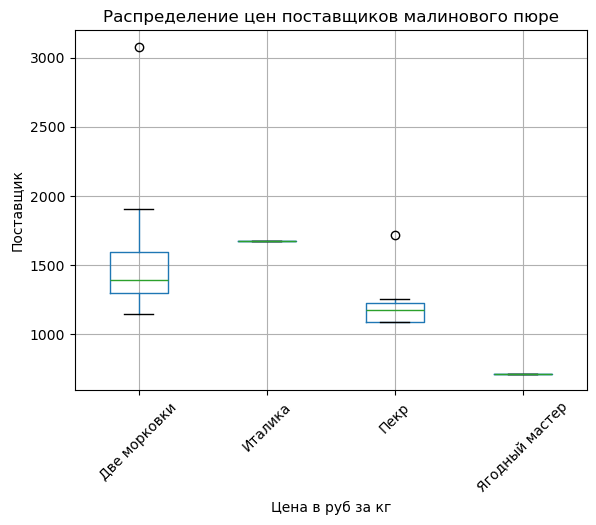

In [288]:
plt.figure(figsize=(8, 6))

df_malina.boxplot(column='цена за кг', by='магазин')

plt.title('Распределение цен поставщиков малинового пюре', fontsize=12)
plt.xlabel('Цена в руб за кг')
plt.ylabel('Поставщик')
plt.xticks(rotation=45)

plt.suptitle('')  
plt.show()

In [289]:
cheap_malina = df_malina.nsmallest(3, 'цена за кг')[['магазин', 'товар', 'цена за кг', 'вес продажи в кг']]
cheap_malina

,магазин,товар,цена за кг,вес продажи в кг
9,Ягодный мастер,Пюре из малины,715.0,1.0
12,Пекр,Замороженное фруктовое пюре Proff Puree Малина...,1090.0,0.5
16,Пекр,Пюре пастеризованное малина РАВИФРУТ (тетрапак...,1090.0,1.0


In [290]:
cheap_lichi = df_lichi.nsmallest(3, 'цена за кг')[['магазин', 'товар', 'цена за кг', 'вес продажи в кг']]
cheap_lichi

,магазин,товар,цена за кг,вес продажи в кг
7,Пекр,Пюре пастеризованное личи РАВИФРУТ (тетрапак 1...,1160.0,1.0
4,Пекр,"Пюре Личи, Fresh Harvest, 1 кг",1165.0,1.0
1,Две морковки,"Пюре замороженное Личи, Fresh Harvest, Россия,...",1190.0,1.0


**Идеальный поставщик для пюре**: 

Пекр. Цена низкая, есть и личи и малина.

_________________________________________________________________________________________________________________________________________________

Популярные поставщики сахара в Москве: Сахаропт [(ссылка)](https://sakharopt.ru/tseny/#price-list), Шугар компания [(ссылка)](https://sugar-company.ru/), Агросервер - агрегирует много небольших поставщиков[(ссылка)](https://agroserver.ru/fast/sakhar/)

**Сахаропт**

У этого поставщика минимальная партия - 10 тонн

In [291]:
url = 'https://sakharopt.ru/tseny/#price-list'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [292]:
soup = BeautifulSoup(response.text, 'html.parser')

In [293]:
sugar = []

In [294]:
table = soup.find('table')
rows = table.find_all('tr')
for row in rows[1:]:
    columns = row.find_all('td')
    name = columns[0].get_text(strip=True)
    quantity = columns[1].get_text(strip=True)
    quantity_g = extract_weight(quantity)
    quantity_kg = quantity_g / 1000
    price = columns[2].get_text(strip=True)
    price = extract_price(price)
    price_kg = price / quantity_kg

    sugar.append({'поставщик': 'Сахаропт', 'товар': name, 'цена за кг': price_kg})

print(sugar)

[{'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ВЕСГОСТ 33222-2015', 'цена за кг': 59.5}, {'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ВЕСГОСТ 33222-2015', 'цена за кг': 59.5}, {'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ФАСГОСТ 33222-2015', 'цена за кг': 59.5}, {'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ФАСГОСТ 33222-2015', 'цена за кг': 59.5}, {'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ФАСГОСТ 33222-2015', 'цена за кг': 59.5}, {'поставщик': 'Сахаропт', 'товар': 'Сахарный песок ФАСГОСТ 33222-2015', 'цена за кг': 59.5}]


In [295]:
df_sugar = pd.DataFrame(sugar)
df_sugar

,поставщик,товар,цена за кг
0,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.5
1,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.5
2,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
3,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
4,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
5,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5


**Шугар компания**

У этого поставщика минимальный вес партии - 1 тонна

In [296]:
url = 'https://sugar-company.ru/'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [297]:
soup = BeautifulSoup(response.text, 'html.parser')

In [298]:
sugar = []

In [299]:
table = soup.find('div', class_ = 'price__table')
products = table.find_all('div', class_ = 'price__table-row')
for product in products[1:]:
    columns = product.find_all('span')
    name = columns[0].get_text(strip=True)
    quantity_kg = float(columns[1].get_text(strip=True))
    price = columns[2].get_text(strip=True)
    price = extract_price(price)
    price_kg = price / quantity_kg

    sugar.append({'поставщик': 'Шугар компания', 'товар': name, 'цена за кг': price_kg})

print(sugar)

[{'поставщик': 'Шугар компания', 'товар': 'Сахарный песок весовой ГОСТ 33222-2015, Мешки 50кг.', 'цена за кг': 63.0}, {'поставщик': 'Шугар компания', 'товар': 'Сахарный песок фасованный по 1кг, ГОСТ 33222-2015, упаковка  10шт', 'цена за кг': 66.4}, {'поставщик': 'Шугар компания', 'товар': 'Сахарный песок фасованный по 5кг, ГОСТ 33222-2015', 'цена за кг': 65.9}, {'поставщик': 'Шугар компания', 'товар': 'Сахарный песок фасованный по 10кг, ГОСТ 33222-2015', 'цена за кг': 65.4}]


In [300]:
for row in sugar:
    df_sugar = pd.concat([df_sugar, pd.DataFrame([row])], ignore_index=True)

df_sugar

,поставщик,товар,цена за кг
0,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.5
1,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.5
2,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
3,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
4,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
5,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.5
6,Шугар компания,"Сахарный песок весовой ГОСТ 33222-2015, Мешки ...",63.0
7,Шугар компания,"Сахарный песок фасованный по 1кг, ГОСТ 33222-2...",66.4
8,Шугар компания,"Сахарный песок фасованный по 5кг, ГОСТ 33222-2015",65.9
9,Шугар компания,"Сахарный песок фасованный по 10кг, ГОСТ 33222-...",65.4


**Агросервер**

In [301]:
url = 'https://agroserver.ru/fast/sakhar/'

response = requests.get(url, headers = headers)
response

<Response [200]>

In [302]:
soup = BeautifulSoup(response.text, 'html.parser')

In [303]:
sugar = []

In [304]:
def price_to_kg(price_text, name=''):
    text = price_text.lower().strip()
    text = re.sub(r'^(от|до)\s*', '', text)
    text = re.sub(r'(\d)\s+(\d)', r'\1\2', text)
    
    num = float(re.search(r'(\d+(?:[.,]\d+)?)', text).group(1).replace(',', '.'))
    
    if 'usd' in text:
        num = num * 71
    if 'т' in text:
        num = num / 1000
    
    return num

In [305]:
sugar = []

In [306]:
table = soup.find('table', class_ = 'table_fast')
rows = table.find_all('tr')
for row in rows:
    name_el = row.find('a', class_ = 'for_clk')
    name = name_el.text
    ignor = ['пудра', 'стик', 'саше', 'рафинад', 'кусковой', 'помадка', 'на экспорт', 'тростник', 'мешок', 'упаковка', 'шт']
    flag = True
    for el in ignor:
        if el in name.lower():
            flag = False
            break
    if flag == True and 'сахар' in name.lower():
        try:
            price_el = row.find('td', class_ = 'price')
            price_text = price_el.text
            if 'мешок' not in price_text.lower():
                price_kg = price_to_kg(price_text)

                proizv_el = row.find_all('a', attrs = {'target': '_blank'})
                proizv = proizv_el[1].text

                sugar.append({'поставщик': proizv, 'товар': name, 'цена за кг': price_kg})
        except:
            continue

print(sugar)

[{'поставщик': 'ООО УК "ДЕЛСО"', 'товар': 'Кокосовый сахар', 'цена за кг': 370.0}, {'поставщик': 'Аслан', 'товар': 'Нават (кристаллический сахар)', 'цена за кг': 170.0}, {'поставщик': 'АО "НОВГОРОДСКОЕ ЗЕРНОВОЕ П...', 'товар': 'Сахар-песок в мешках 50 кг оптом', 'цена за кг': 48.0}, {'поставщик': 'ИП Агиевич Дарья Сергеевна', 'товар': 'Сахар', 'цена за кг': 56.0}, {'поставщик': 'ООО "ЛАС-ФЛОРЕС ГРУПП"', 'товар': 'Сахар кокосовый, Шри Ланка', 'цена за кг': 558.0}, {'поставщик': 'ООО "АНБ"', 'товар': 'Кокосовый сахар', 'цена за кг': 400.0}, {'поставщик': 'ООО "КОНКОРД"', 'товар': 'Сахар в мешках по 50 кг', 'цена за кг': 45.0}, {'поставщик': 'ООО "ВЕДДА"', 'товар': 'Кокосовый сахар, Индонезия 1 кг', 'цена за кг': 595.0}, {'поставщик': 'Иван', 'товар': 'ПРОДАМ САХАР НЕКОНДИЦИЯ ( ПИЩЕВОЙ) СМЕШАН С КАКАО, ОБЬЕМ 20 Т ОТГРУЗКА МОСКВА', 'цена за кг': 23.0}, {'поставщик': 'ООО "АЛТАЙСКОЕ ПОЛЮШКО"', 'товар': 'Сахар', 'цена за кг': 66.0}, {'поставщик': 'ООО "ГЛОБАЛ ФУД"', 'товар': 'Набот / Набат /

In [307]:
for row in sugar:
    df_sugar = pd.concat([df_sugar, pd.DataFrame([row])], ignore_index=True)

df_sugar

,поставщик,товар,цена за кг
0,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.500
1,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.500
2,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500
3,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500
4,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500
...,...,...,...
89,"ООО ""МОС ЯРД ИНВЕСТ""",Сахар,35.000
90,Александр,САХАР СВЕКЛОВИЧНЫЙ БРАЗИЛЬСКИЙ,35.145
91,Артем,Сахар,45.000
92,"ООО ""ИНТЕГРАЛ""",Тросниковый сахар (Бразилия)/Cane sugar from B...,31.595


Посмотрим какие типы сахара самые дорогие

In [308]:
def cat_sugar(name):
    name_lower = name.lower()
    if 'кокосовый' in name_lower:
        return 'Кокосовый'
    elif 'тростник' in name_lower or 'cane' in name_lower:
        return 'Тростниковый'
    elif 'ванильный' in name_lower:
        return 'Ванильный'
    elif 'нават' in name_lower or 'набат' in name_lower:
        return 'Нават'
    elif 'бpaзильский' in name_lower or 'icumsa' in name_lower:
        return 'Бразильский'
    else:
        return 'Обычный'

df_sugar['тип'] = df_sugar['товар'].apply(cat_sugar)
df_sugar

,поставщик,товар,цена за кг,тип
0,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.500,Обычный
1,Сахаропт,Сахарный песок ВЕСГОСТ 33222-2015,59.500,Обычный
2,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500,Обычный
3,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500,Обычный
4,Сахаропт,Сахарный песок ФАСГОСТ 33222-2015,59.500,Обычный
...,...,...,...,...
89,"ООО ""МОС ЯРД ИНВЕСТ""",Сахар,35.000,Обычный
90,Александр,САХАР СВЕКЛОВИЧНЫЙ БРАЗИЛЬСКИЙ,35.145,Обычный
91,Артем,Сахар,45.000,Обычный
92,"ООО ""ИНТЕГРАЛ""",Тросниковый сахар (Бразилия)/Cane sugar from B...,31.595,Тростниковый


In [309]:
statis = df_sugar.groupby('тип')['цена за кг'].agg(['min', 'mean']).round(2)
statis.columns = ['минимальная цена', 'средняя цена']

statis

,минимальная цена,средняя цена
тип,,
Бразильский,21.30,26.27
Ванильный,130.00,165.00
Кокосовый,175.00,450.33
Нават,140.00,170.00
Обычный,0.05,58.88
Тростниковый,31.60,31.60


Посмотрим на самых дешевых поставщиков

In [310]:
cheapest = df_sugar.nsmallest(10, 'цена за кг')[['поставщик', 'товар', 'цена за кг']]
cheapest

,поставщик,товар,цена за кг
78,Антей,Сахар,0.05000
42,Сергей,"Сахар песок Виктория 0,9кг",0.05098
85,Александр,Бразильский сахар ICUMSA 45,21.30000
18,Иван,ПРОДАМ САХАР НЕКОНДИЦИЯ ( ПИЩЕВОЙ) СМЕШАН С КА...,23.00000
93,"ООО ""ИНТЕГРАЛ""","WHITE REFINED SUGAR ICUMSA 45, ICUMSA 150 BRAZ...",31.24000
92,"ООО ""ИНТЕГРАЛ""",Тросниковый сахар (Бразилия)/Cane sugar from B...,31.59500
89,"ООО ""МОС ЯРД ИНВЕСТ""",Сахар,35.00000
90,Александр,САХАР СВЕКЛОВИЧНЫЙ БРАЗИЛЬСКИЙ,35.14500
54,"ООО ""ЭНДОРФИН""",Сахар,44.00000
16,"ООО ""КОНКОРД""",Сахар в мешках по 50 кг,45.00000


**Выводы**

Отбрасываем первие два варианта и сахар некондицию, так как там поставщики странные, скорее всего частные лица, и цена слишокм низкая. Тогда топ-3 потенциальных поставщиков сахара:

1. ООО "ИНТЕГРАЛ
2. ООО "МОС ЯРД ИНВЕСТ"
3. ООО "ЭНДОРФИН"
